In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
plt.rcParams.update({
    'figure.facecolor': '#0d1929',
    'axes.facecolor':   '#080c14',
    'axes.edgecolor':   '#1a2e4a',
    'axes.labelcolor':  '#8aaccc',
    'text.color':       '#c8d6f0',
    'xtick.color':      '#5a7090',
    'ytick.color':      '#5a7090',
    'grid.color':       '#1a2e4a',
    'grid.alpha':       0.5,
})

print("All libraries imported successfully.")

All libraries imported successfully.


In [16]:
# Load Digits dataset — 8x8 pixel handwritten digit images, 10 classes (0-9)
digits = load_digits()
X = digits.data          # shape: (1797, 64)
y = digits.target        # labels: 0 through 9

print("Dataset Shape       :", X.shape)
print("Number of Classes   :", len(digits.target_names))
print("Class Labels        :", digits.target_names)
print("Samples per class   :", np.bincount(y))

# Standardize features (important for KNN — distance-based)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Validation/Test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42, stratify=y_trainval
)

print(f"\nTrain     : {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test      : {X_test.shape[0]} samples")

Dataset Shape       : (1797, 64)
Number of Classes   : 10
Class Labels        : [0 1 2 3 4 5 6 7 8 9]
Samples per class   : [178 182 177 183 181 182 181 179 174 180]

Train     : 1149 samples
Validation: 288 samples
Test      : 360 samples


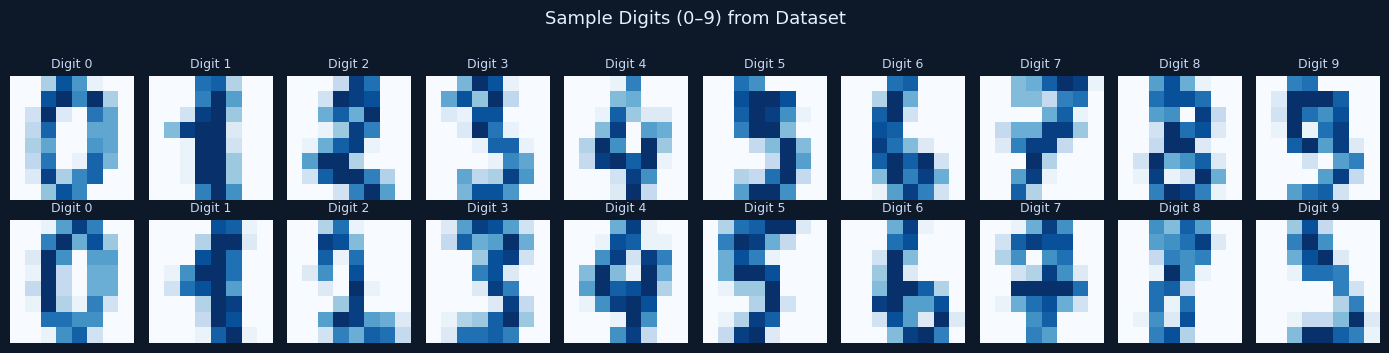

Sample digits plot saved.


In [17]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for digit in range(10):
    idx = np.where(y == digit)[0][:2]
    for row, i in enumerate(idx):
        axes[row, digit].imshow(digits.images[i], cmap='Blues', interpolation='nearest')
        axes[row, digit].set_title(f"Digit {digit}", fontsize=9, color='#c8d6f0')
        axes[row, digit].axis('off')
plt.suptitle("Sample Digits (0–9) from Dataset", fontsize=13, color='#e8f0ff', y=1.02)
plt.tight_layout()
plt.savefig('digit_samples.png', dpi=130, bbox_inches='tight',
            facecolor='#0d1929')
plt.show()
print("Sample digits plot saved.")

In [18]:
k_values     = list(range(1, 21))
val_accs     = []
train_accs   = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_accs.append(accuracy_score(y_val, knn.predict(X_val)))
    train_accs.append(accuracy_score(y_train, knn.predict(X_train)))

best_k   = k_values[np.argmax(val_accs)]
best_acc = max(val_accs)

print("K-value Accuracy Table:")
print(f"{'K':>4} | {'Val Acc':>10} | {'Train Acc':>10}")
print("-" * 32)
for k, va, ta in zip(k_values, val_accs, train_accs):
    marker = "  <-- BEST" if k == best_k else ""
    print(f"{k:>4} | {va:>10.4f} | {ta:>10.4f}{marker}")

print(f"\nBest K = {best_k} with Validation Accuracy = {best_acc:.4f}")

K-value Accuracy Table:
   K |    Val Acc |  Train Acc
--------------------------------
   1 |     0.9688 |     1.0000  <-- BEST
   2 |     0.9549 |     0.9861
   3 |     0.9653 |     0.9913
   4 |     0.9583 |     0.9826
   5 |     0.9618 |     0.9835
   6 |     0.9618 |     0.9817
   7 |     0.9618 |     0.9826
   8 |     0.9583 |     0.9782
   9 |     0.9653 |     0.9826
  10 |     0.9618 |     0.9756
  11 |     0.9653 |     0.9756
  12 |     0.9618 |     0.9765
  13 |     0.9583 |     0.9774
  14 |     0.9549 |     0.9774
  15 |     0.9549 |     0.9713
  16 |     0.9618 |     0.9695
  17 |     0.9618 |     0.9661
  18 |     0.9549 |     0.9643
  19 |     0.9514 |     0.9626
  20 |     0.9549 |     0.9634

Best K = 1 with Validation Accuracy = 0.9688


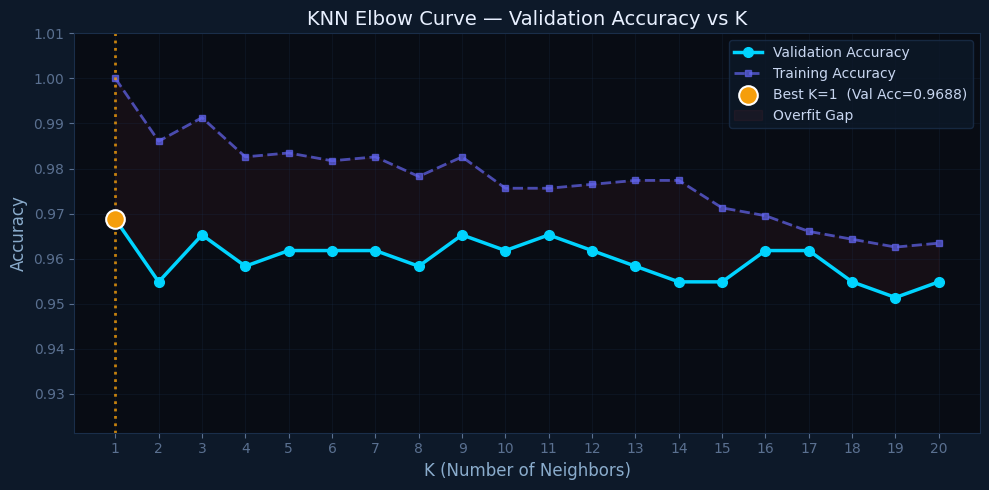

Elbow curve saved. Best K = 1


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_values, val_accs,   color='#00d4ff', linewidth=2.5, marker='o',
        markersize=7, label='Validation Accuracy')
ax.plot(k_values, train_accs, color='#6366f1', linewidth=2.0, marker='s',
        markersize=5, linestyle='--', alpha=0.7, label='Training Accuracy')

# Highlight best K
ax.axvline(best_k, color='#f59e0b', linestyle=':', linewidth=2, alpha=0.8)
ax.scatter([best_k], [best_acc], s=180, color='#f59e0b', zorder=6,
           edgecolors='white', linewidths=1.5,
           label=f'Best K={best_k}  (Val Acc={best_acc:.4f})')

# Fill overfit zone
ax.fill_between(k_values, train_accs, val_accs,
                alpha=0.06, color='#ef4444', label='Overfit Gap')

ax.set_xlabel("K (Number of Neighbors)", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("KNN Elbow Curve — Validation Accuracy vs K", fontsize=14, color='#e8f0ff')
ax.set_xticks(k_values)
ax.legend(facecolor='#0d1929', edgecolor='#1a2e4a', labelcolor='#c8d6f0', fontsize=10)
ax.grid(True, alpha=0.25)
ax.set_ylim([min(val_accs)-0.03, 1.01])

plt.tight_layout()
plt.savefig('knn_elbow.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print(f"Elbow curve saved. Best K = {best_k}")

In [20]:
# Reduce 64 features to 2 PCA components for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)
X_all_pca   = pca.transform(X_scaled)

print(f"PCA Explained Variance  : {pca.explained_variance_ratio_}")
print(f"Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Create mesh for decision boundary
margin = 1.5
x_min = X_all_pca[:,0].min() - margin
x_max = X_all_pca[:,0].max() + margin
y_min = X_all_pca[:,1].min() - margin
y_max = X_all_pca[:,1].max() + margin

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250)
)
grid = np.c_[xx.ravel(), yy.ravel()]
print("Mesh grid prepared for decision boundaries.")

PCA Explained Variance  : [0.12524117 0.10144819]
Total Variance Explained: 22.67%
Mesh grid prepared for decision boundaries.


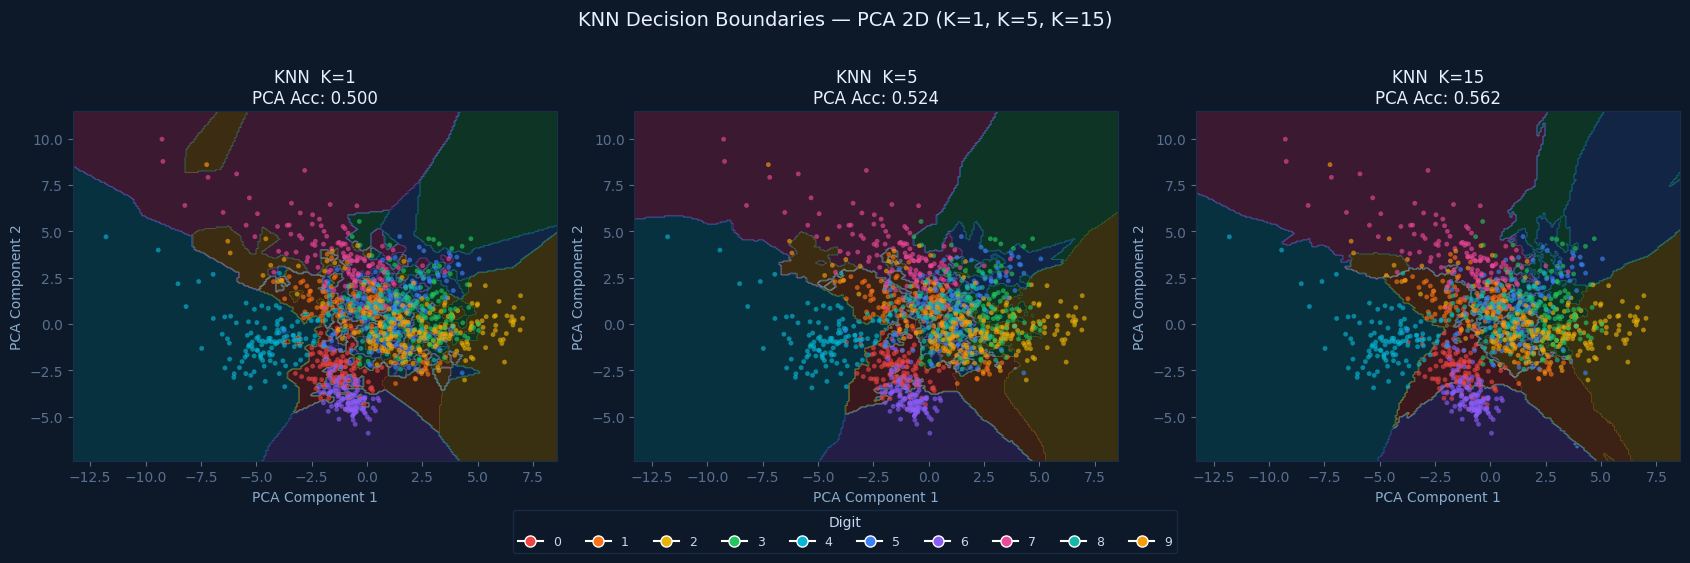

Decision boundary plot saved.


In [21]:
k_plot_values = [1, 5, 15]

# 10-color palette for digits 0-9
palette = ['#ef4444','#f97316','#eab308','#22c55e','#06b6d4',
           '#3b82f6','#8b5cf6','#ec4899','#14b8a6','#f59e0b']
cmap_boundary = mcolors.ListedColormap(palette)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, k in zip(axes, k_plot_values):
    # Train KNN on 2D PCA features
    knn_2d = KNeighborsClassifier(n_neighbors=k)
    knn_2d.fit(X_train_pca, y_train)

    # Predict on mesh
    Z = knn_2d.predict(grid).reshape(xx.shape)
    acc_2d = accuracy_score(y_val, knn_2d.predict(X_val_pca))

    ax.contourf(xx, yy, Z, alpha=0.22, cmap=cmap_boundary,
                levels=np.arange(-0.5, 10, 1))

    # Plot each class as scatter
    for digit in range(10):
        mask = y_train == digit
        ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                   color=palette[digit], s=12, alpha=0.65,
                   edgecolors='none', label=str(digit))

    ax.set_xlabel("PCA Component 1", fontsize=10)
    ax.set_ylabel("PCA Component 2", fontsize=10)
    ax.set_title(f"KNN  K={k}\nPCA Acc: {acc_2d:.3f}", fontsize=12, color='#e8f0ff')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

handles = [plt.Line2D([0],[0], marker='o', color='w',
           markerfacecolor=palette[i], markersize=8, label=str(i)) for i in range(10)]
fig.legend(handles=handles, title="Digit", loc='lower center',
           ncol=10, fontsize=9, facecolor='#0d1929', edgecolor='#1a2e4a',
           labelcolor='#c8d6f0', bbox_to_anchor=(0.5, -0.08))

plt.suptitle("KNN Decision Boundaries — PCA 2D (K=1, K=5, K=15)", fontsize=14,
             color='#e8f0ff', y=1.02)
plt.tight_layout()
plt.savefig('knn_decision_boundary.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("Decision boundary plot saved.")

In [22]:
# Train best KNN on full 64-feature data (not PCA)
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)

knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec  = recall_score(y_test, y_pred_knn, average='weighted')
knn_f1   = f1_score(y_test, y_pred_knn, average='weighted')

print(f"Best KNN (K={best_k}) — Test Evaluation")
print("=" * 45)
print(f"  Accuracy   : {knn_acc:.4f}")
print(f"  Precision  : {knn_prec:.4f}")
print(f"  Recall     : {knn_rec:.4f}")
print(f"  F1 Score   : {knn_f1:.4f}")
print()
print(classification_report(y_test, y_pred_knn,
      target_names=[str(i) for i in range(10)]))

Best KNN (K=1) — Test Evaluation
  Accuracy   : 0.9667
  Precision  : 0.9671
  Recall     : 0.9667
  F1 Score   : 0.9665

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      1.00      0.99        37
           4       0.94      0.94      0.94        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       0.94      0.89      0.91        35
           9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [23]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

gnb_acc  = accuracy_score(y_test, y_pred_gnb)
gnb_prec = precision_score(y_test, y_pred_gnb, average='weighted')
gnb_rec  = recall_score(y_test, y_pred_gnb, average='weighted')
gnb_f1   = f1_score(y_test, y_pred_gnb, average='weighted')

print("GaussianNB — Test Evaluation")
print("=" * 45)
print(f"  Accuracy   : {gnb_acc:.4f}")
print(f"  Precision  : {gnb_prec:.4f}")
print(f"  Recall     : {gnb_rec:.4f}")
print(f"  F1 Score   : {gnb_f1:.4f}")
print()
print(classification_report(y_test, y_pred_gnb,
      target_names=[str(i) for i in range(10)]))

GaussianNB — Test Evaluation
  Accuracy   : 0.7583
  Precision  : 0.8120
  Recall     : 0.7583
  F1 Score   : 0.7549

              precision    recall  f1-score   support

           0       0.97      0.92      0.94        36
           1       0.54      0.86      0.67        36
           2       0.88      0.40      0.55        35
           3       0.89      0.43      0.58        37
           4       0.96      0.75      0.84        36
           5       0.84      0.97      0.90        37
           6       0.88      0.97      0.92        36
           7       0.76      0.97      0.85        36
           8       0.44      0.69      0.53        35
           9       0.96      0.61      0.75        36

    accuracy                           0.76       360
   macro avg       0.81      0.76      0.75       360
weighted avg       0.81      0.76      0.75       360



In [24]:
# Synthetic News Categories Dataset (6 categories, 1800 documents)
# Simulates 20newsgroups-style classification with TF-IDF + MultinomialNB

np.random.seed(42)

categories_vocab = {
    'sports':     ['goal','team','player','game','win','score','match','league',
                   'coach','ball','season','championship','tournament','athlete','stadium',
                   'referee','penalty','transfer','manager','contract'],
    'politics':   ['government','election','president','policy','vote','senate',
                   'congress','law','minister','campaign','party','debate',
                   'reform','democracy','bill','parliament','diplomat','treaty','constitution','tax'],
    'technology': ['software','computer','internet','algorithm','data','network',
                   'code','server','cloud','artificial','machine','digital','system',
                   'device','platform','startup','cybersecurity','blockchain','quantum','robotics'],
    'science':    ['research','study','experiment','discovery','theory','molecule',
                   'particle','space','climate','biology','physics','chemistry',
                   'laboratory','scientist','evolution','genome','asteroid','gravity','neuron','ecosystem'],
    'business':   ['market','company','stock','economy','trade','profit','invest',
                   'finance','revenue','startup','corporate','CEO','industry',
                   'growth','merger','acquisition','dividend','bankruptcy','tariff','inflation'],
    'health':     ['disease','treatment','medicine','patient','hospital','doctor',
                   'therapy','vaccine','symptom','diet','exercise','mental','clinical',
                   'surgery','drug','nutrition','pandemic','antibiotic','diagnosis','wellbeing'],
}

cat_names_text = list(categories_vocab.keys())
common_words = ['the','is','was','are','has','have','this','that','with',
                'for','and','but','or','in','on','at','to','of','a','an',
                'it','its','their','there','they','from','about','said','new']

def make_document(cat_words, n_words=80):
    content_words = np.random.choice(cat_words, size=n_words * 2 // 3, replace=True).tolist()
    filler_words  = np.random.choice(common_words, size=n_words // 3, replace=True).tolist()
    all_words = content_words + filler_words
    np.random.shuffle(all_words)
    return ' '.join(all_words)

text_docs, text_labels = [], []
for i, (cat, vocab) in enumerate(categories_vocab.items()):
    for _ in range(300):         # 300 docs per category = 1800 total
        text_docs.append(make_document(vocab))
        text_labels.append(i)

text_docs   = np.array(text_docs)
text_labels = np.array(text_labels)

print("Text Dataset Summary")
print("=" * 40)
print(f"  Total documents  : {len(text_docs)}")
print(f"  Categories       : {len(cat_names_text)}")
print(f"  Category names   : {cat_names_text}")
print(f"  Docs per category: {np.bincount(text_labels)}")
print()
print("Sample document (sports category):")
print(" ", text_docs[0][:120], "...")

Text Dataset Summary
  Total documents  : 1800
  Categories       : 6
  Category names   : ['sports', 'politics', 'technology', 'science', 'business', 'health']
  Docs per category: [300 300 300 300 300 300]

Sample document (sports category):
  on athlete league for championship manager contract game match coach penalty from team in manager match ball transfer se ...


In [25]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_text = tfidf.fit_transform(text_docs)

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text, text_labels, test_size=0.20, random_state=42, stratify=text_labels
)

print(f"TF-IDF Feature Matrix shape : {X_text.shape}")
print(f"Train samples               : {X_text_train.shape[0]}")
print(f"Test  samples               : {X_text_test.shape[0]}")
print(f"Vocabulary size             : {len(tfidf.vocabulary_)}")

# Train MultinomialNB
mnb = MultinomialNB(alpha=0.1)
mnb.fit(X_text_train, y_text_train)
y_pred_mnb = mnb.predict(X_text_test)

mnb_acc  = accuracy_score(y_text_test, y_pred_mnb)
mnb_prec = precision_score(y_text_test, y_pred_mnb, average='weighted')
mnb_rec  = recall_score(y_text_test, y_pred_mnb, average='weighted')
mnb_f1   = f1_score(y_text_test, y_pred_mnb, average='weighted')

print(f"\nMultinomialNB — Text Classification Results")
print("=" * 50)
print(f"  Accuracy   : {mnb_acc:.4f}")
print(f"  Precision  : {mnb_prec:.4f}")
print(f"  Recall     : {mnb_rec:.4f}")
print(f"  F1 Score   : {mnb_f1:.4f}")
print()
print(classification_report(y_text_test, y_pred_mnb, target_names=cat_names_text))

TF-IDF Feature Matrix shape : (1800, 5000)
Train samples               : 1440
Test  samples               : 360
Vocabulary size             : 5000

MultinomialNB — Text Classification Results
  Accuracy   : 1.0000
  Precision  : 1.0000
  Recall     : 1.0000
  F1 Score   : 1.0000

              precision    recall  f1-score   support

      sports       1.00      1.00      1.00        60
    politics       1.00      1.00      1.00        60
  technology       1.00      1.00      1.00        60
     science       1.00      1.00      1.00        60
    business       1.00      1.00      1.00        60
      health       1.00      1.00      1.00        60

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



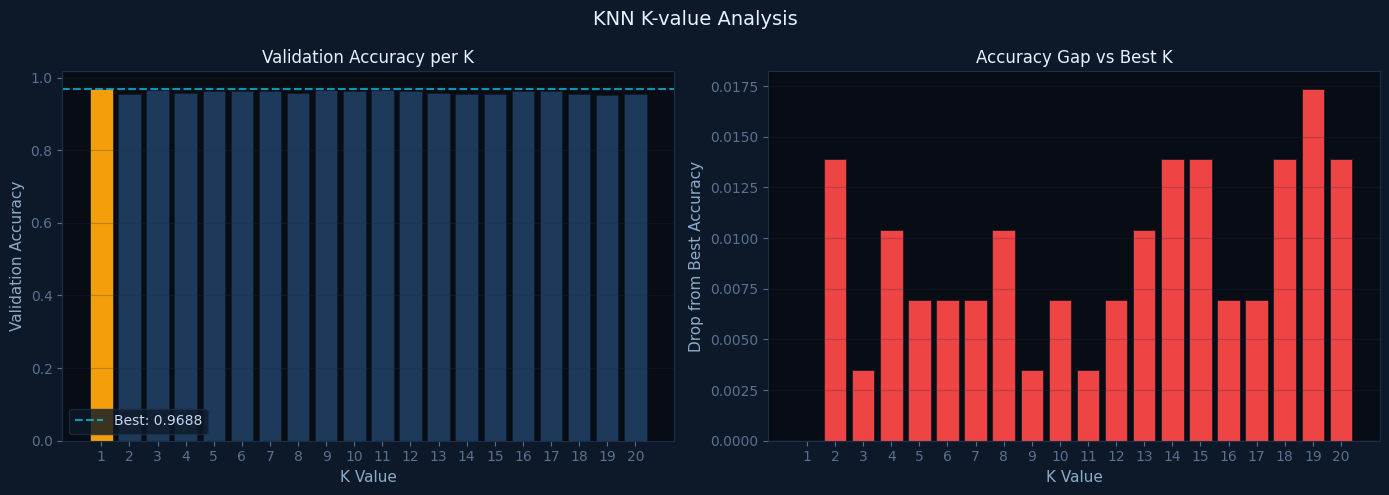

K-value analysis plot saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = ['#f59e0b' if k == best_k else '#1e3a5a' for k in k_values]
axes[0].bar(k_values, val_accs, color=colors_bar, edgecolor='#0d1929', linewidth=0.5)
axes[0].axhline(best_acc, color='#00d4ff', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Best: {best_acc:.4f}')
axes[0].set_xlabel("K Value", fontsize=11)
axes[0].set_ylabel("Validation Accuracy", fontsize=11)
axes[0].set_title("Validation Accuracy per K", fontsize=12, color='#e8f0ff')
axes[0].set_xticks(k_values)
axes[0].legend(facecolor='#0d1929', edgecolor='#1a2e4a', labelcolor='#c8d6f0')
axes[0].grid(True, axis='y', alpha=0.25)

# Accuracy diff from best
diffs = [best_acc - a for a in val_accs]
clr2  = ['#ef4444' if d > 0 else '#10b981' for d in diffs]
axes[1].bar(k_values, diffs, color=clr2, edgecolor='#0d1929', linewidth=0.5)
axes[1].axhline(0, color='white', linewidth=0.8, alpha=0.5)
axes[1].set_xlabel("K Value", fontsize=11)
axes[1].set_ylabel("Drop from Best Accuracy", fontsize=11)
axes[1].set_title("Accuracy Gap vs Best K", fontsize=12, color='#e8f0ff')
axes[1].set_xticks(k_values)
axes[1].grid(True, axis='y', alpha=0.25)

plt.suptitle("KNN K-value Analysis", fontsize=14, color='#e8f0ff')
plt.tight_layout()
plt.savefig('knn_k_analysis.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("K-value analysis plot saved.")

In [27]:
print("=" * 80)
print(f"{'MODEL':<35} {'ACCURACY':>10} {'PRECISION':>11} {'RECALL':>9} {'F1':>9}")
print("=" * 80)

rows = [
    (f"KNN  (K={best_k}, full 64 features)",  knn_acc,  knn_prec,  knn_rec,  knn_f1),
    (f"GaussianNB (full 64 features)",         gnb_acc,  gnb_prec,  gnb_rec,  gnb_f1),
    (f"MultinomialNB (TF-IDF text, 6-class)",  mnb_acc,  mnb_prec,  mnb_rec,  mnb_f1),
]
for name, acc, prec, rec, f1 in rows:
    print(f"  {name:<33} {acc:>10.4f} {prec:>11.4f} {rec:>9.4f} {f1:>9.4f}")

print("=" * 80)
print()

# DataFrame summary
df_comparison = pd.DataFrame({
    'Model':     [f'KNN (K={best_k})', 'GaussianNB', 'MultinomialNB (Text)'],
    'Dataset':   ['Digits (64 feat)', 'Digits (64 feat)', 'News (TF-IDF 5000)'],
    'Accuracy':  [knn_acc,  gnb_acc,  mnb_acc],
    'Precision': [knn_prec, gnb_prec, mnb_prec],
    'Recall':    [knn_rec,  gnb_rec,  mnb_rec],
    'F1 Score':  [knn_f1,   gnb_f1,   mnb_f1],
})
print(df_comparison.round(4).to_string(index=False))
print()
print("Notes:")
print("  KNN   = Non-parametric, distance-based, sensitive to feature scaling.")
print("  GNB   = Assumes Gaussian distribution per feature per class.")
print("  MNB   = Designed for count/frequency data (text), used with TF-IDF.")

MODEL                                 ACCURACY   PRECISION    RECALL        F1
  KNN  (K=1, full 64 features)          0.9667      0.9671    0.9667    0.9665
  GaussianNB (full 64 features)         0.7583      0.8120    0.7583    0.7549
  MultinomialNB (TF-IDF text, 6-class)     1.0000      1.0000    1.0000    1.0000

               Model            Dataset  Accuracy  Precision  Recall  F1 Score
           KNN (K=1)   Digits (64 feat)    0.9667     0.9671  0.9667    0.9665
          GaussianNB   Digits (64 feat)    0.7583     0.8120  0.7583    0.7549
MultinomialNB (Text) News (TF-IDF 5000)    1.0000     1.0000  1.0000    1.0000

Notes:
  KNN   = Non-parametric, distance-based, sensitive to feature scaling.
  GNB   = Assumes Gaussian distribution per feature per class.
  MNB   = Designed for count/frequency data (text), used with TF-IDF.


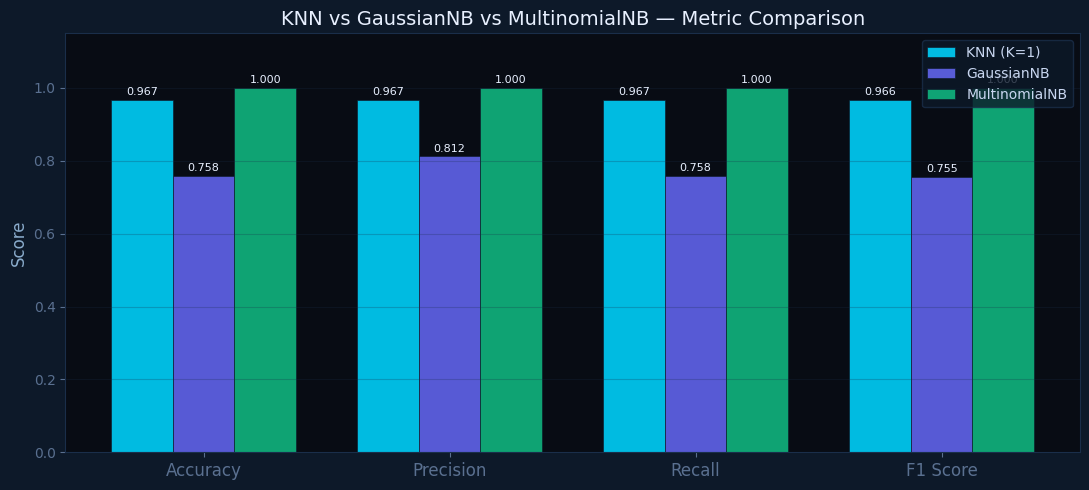

Comparison chart saved.


In [28]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names   = [f'KNN (K={best_k})', 'GaussianNB', 'MultinomialNB']
model_scores  = [
    [knn_acc,  knn_prec,  knn_rec,  knn_f1],
    [gnb_acc,  gnb_prec,  gnb_rec,  gnb_f1],
    [mnb_acc,  mnb_prec,  mnb_rec,  mnb_f1],
]
model_colors = ['#00d4ff', '#6366f1', '#10b981']

x   = np.arange(len(metrics_names))
w   = 0.25
fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, scores, clr) in enumerate(zip(model_names, model_scores, model_colors)):
    bars = ax.bar(x + i*w, scores, w, label=model,
                  color=clr, alpha=0.88, edgecolor='#0d1929', linewidth=0.5)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, color='#e8f0ff')

ax.set_xticks(x + w)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title("KNN vs GaussianNB vs MultinomialNB — Metric Comparison", fontsize=14, color='#e8f0ff')
ax.legend(facecolor='#0d1929', edgecolor='#1a2e4a', labelcolor='#c8d6f0', fontsize=10)
ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=130, bbox_inches='tight', facecolor='#0d1929')
plt.show()
print("Comparison chart saved.")